## 1. Load Data ##

In [13]:
import pandas as pd

from pathlib import Path

Path("../outputs/figures").mkdir(
    parents=True,
    exist_ok=True
)

df = pd.read_csv(
    "../data/processed/cleaned_jobs.csv"
)

print(df.shape)
df.head()

(944, 14)


,job_title,seniority_level,status,company,location,post_date,headquarter,industry,ownership,company_size,revenue,salary,skills,salary_numeric
0,data scientist,senior,hybrid,company_003,"Grapevine, TX . Hybrid",NaN,"Bentonville, AR, US",Retail,Public,€352.44B,Public,"€100,472 - €200,938","['spark', 'r', 'python', 'scala', 'machine lea...",150705.0
1,data scientist,lead,hybrid,company_005,"Fort Worth, TX . Hybrid",NaN,"Detroit, MI, US",Manufacturing,Public,"155,030",€51.10B,"€118,733","['spark', 'r', 'python', 'sql', 'machine learn...",118733.0
2,data scientist,senior,on-site,company_007,"Austin, TX . Toronto, Ontario, Canada . Kirkla...",NaN,"Redwood City, CA, US",Technology,Public,"25,930",€33.80B,"€94,987 - €159,559","['aws', 'git', 'python', 'docker', 'sql', 'mac...",127273.0
3,data scientist,senior,hybrid,company_008,"Chicago, IL . Scottsdale, AZ . Austin, TX . Hy...",NaN,"San Jose, CA, US",Technology,Public,"34,690",€81.71B,"€112,797 - €194,402","['sql', 'r', 'python']",153599.5
4,data scientist,Unknown,on-site,company_009,On-site,NaN,"Stamford, CT, US",Finance,Private,"1,800",Private,"€114,172 - €228,337",[],171254.5


## 2. Create Text ##

In [14]:
import ast

df["skills"] = df["skills"].apply(ast.literal_eval)

df["cluster_text"] = (
    df["job_title"].astype(str)
    + " "
    + df["industry"].astype(str)
    + " "
    + df["skills"].apply(lambda x: " ".join(x))
)

## 3. TF-IDF ##

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english"
)

X = vectorizer.fit_transform(
    df["cluster_text"]
)

## 4. KMeans ##

In [16]:
from sklearn.cluster import KMeans

model = KMeans(
    n_clusters=5,
    random_state=42
)

df["cluster"] = model.fit_predict(X)

## 5. Cluster Counts ##

In [17]:
df["cluster"] \
    .value_counts()

cluster
1    353
0    212
2    171
4    104
3    104
Name: count, dtype: int64

## 6. Save ##

In [18]:
df.to_csv(
    "../data/processed/clustered_jobs.csv",
    index=False
)

## 7. Cluster Distribution ##

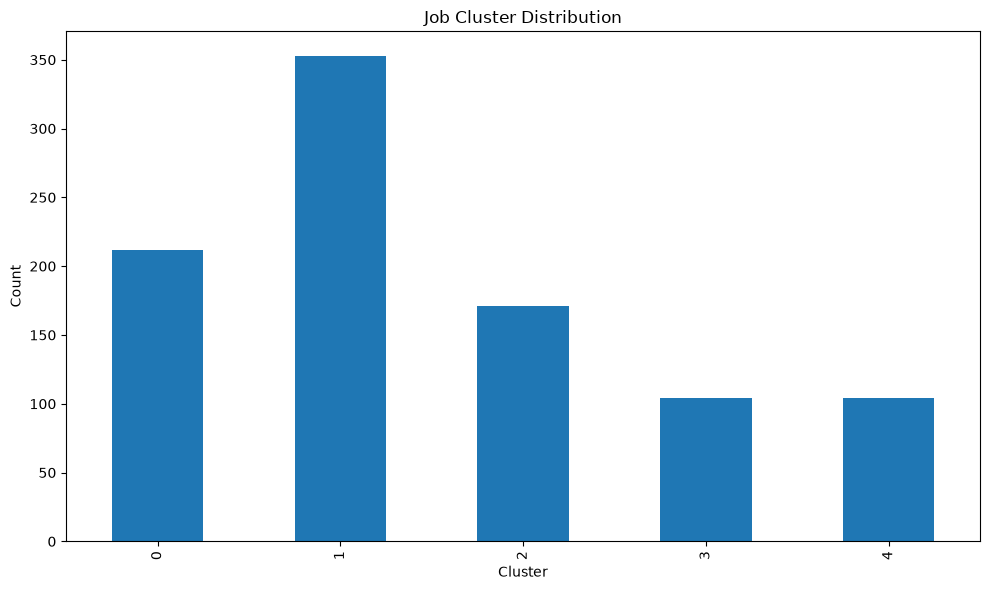

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

df["cluster"] \
    .value_counts() \
    .sort_index() \
    .plot(kind="bar")

plt.title("Job Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/job_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 8. Cluster Visualization (PCA) ##

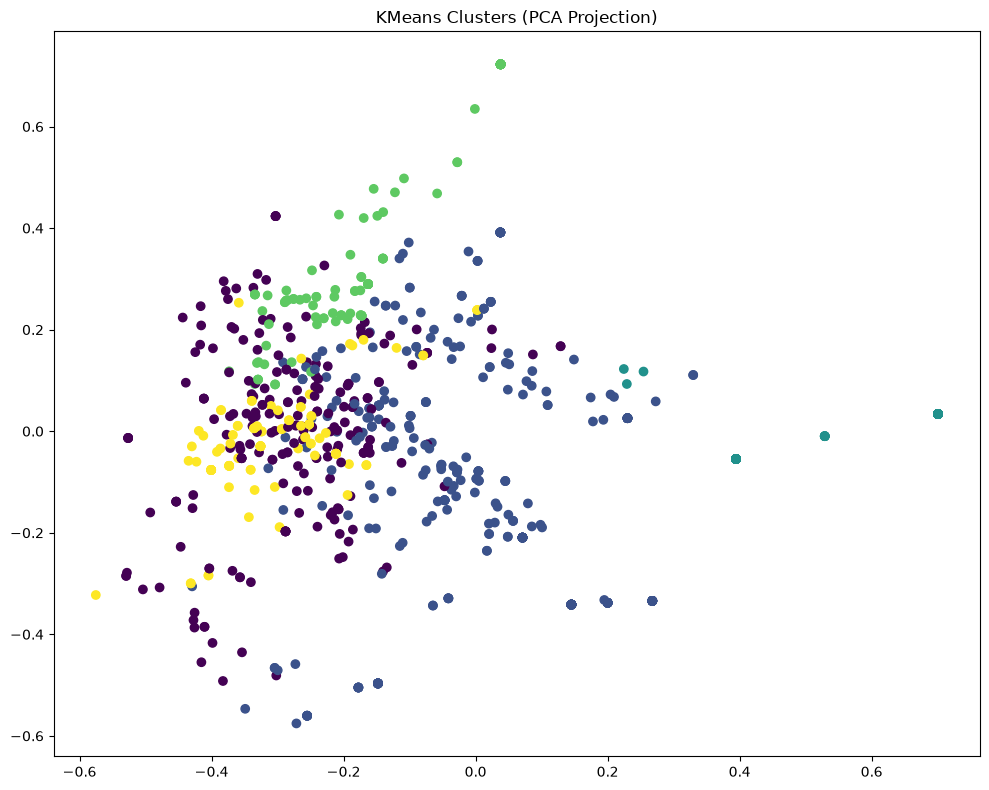

In [20]:
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(
    X.toarray()
)

plt.figure(figsize=(10,8))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["cluster"]
)

plt.title("KMeans Clusters (PCA Projection)")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/job_clusters_pca.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()